# ME455 Homework 5

## Problem 1
We have a 1m-by-1m search space and the target spatial distribution as a Gaussian
mixture distribution speciﬁed as follows:

```
[see assignment pdf]
```
Generate an ergodic trajectory with a time horizon
of 10 seconds with dt = 0.1s.

Turn in: A ﬁgure with 3 plots showing: (1) The converged ergodic trajectory; (2) Optimal
control signals; (3) The evolution of objective value over iterations. An example is shown
below.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal as mvn
from scipy.integrate import solve_bvp

In [2]:
# search space and time discretization
L_list = np.array([1.0, 1.0])
dt = 0.1
tsteps = 100  # T = 10 s
T = tsteps * dt
x0 = np.array([0.3, 0.3])

# Gaussian mixture target distribution
weights = [0.5, 0.2, 0.3]
means = [np.array([0.35, 0.38]), np.array([0.68, 0.25]), np.array([0.56, 0.64])]
covs = [np.array([[0.01, 0.004], [0.004, 0.01]]),
        np.array([[0.005, -0.003], [-0.003, 0.005]]),
        np.array([[0.008, 0.0], [0.0, 0.004]])]


def pdf(x):
    return sum(w * mvn.pdf(x, m, c) for w, m, c in zip(weights, means, covs))


# Fourier basis setup: 10 coefficients per dimension -> 100 index vectors
num_k_per_dim = 10
ks_dim1, ks_dim2 = np.meshgrid(np.arange(num_k_per_dim), np.arange(num_k_per_dim))
ks = np.array([ks_dim1.ravel(), ks_dim2.ravel()]).T

grids_x, grids_y = np.meshgrid(np.linspace(0, L_list[0], 100), np.linspace(0, L_list[1], 100))
grids = np.array([grids_x.ravel(), grids_y.ravel()]).T
dx = 1.0 / 99
dy = 1.0 / 99

# normalization terms h_k, metric weights lambda_k, and target coefficients phi_k
fk_grid = np.prod(np.cos(np.pi * ks[:, np.newaxis] / L_list * grids), axis=2)
hk_list = np.sqrt(np.sum(np.square(fk_grid), axis=1) * dx * dy)
fk_grid /= hk_list[:, np.newaxis]
lamk_list = np.power(1.0 + np.linalg.norm(ks, axis=1), -3.0 / 2.0)
phik_list = np.sum(pdf(grids) * fk_grid, axis=1) * dx * dy

# objective parameters
q = 1.0
R_u = np.diag([0.001, 0.001])
Q_z = np.diag([0.01, 0.01])
R_v = np.diag([0.001, 0.001])
R_v_inv = np.linalg.inv(R_v)


def traj_ck(x_traj):
    fk_traj = np.prod(np.cos(np.pi * ks[:, np.newaxis] / L_list * x_traj), axis=2) / hk_list[:, np.newaxis]
    return np.sum(fk_traj, axis=1) * dt / T


def ergodic_metric(x_traj):
    return np.sum(lamk_list * np.square(traj_ck(x_traj) - phik_list))


def erg_grad(x_traj):
    """Gradient of the ergodic metric w.r.t. each trajectory state -> a_list."""
    k1 = ks[:, 0:1] * np.pi / L_list[0]
    k2 = ks[:, 1:2] * np.pi / L_list[1]
    c1 = np.cos(k1 * x_traj[:, 0])
    s1 = np.sin(k1 * x_traj[:, 0])
    c2 = np.cos(k2 * x_traj[:, 1])
    s2 = np.sin(k2 * x_traj[:, 1])
    ck_list = np.sum(c1 * c2 / hk_list[:, np.newaxis], axis=1) * dt / T
    coeff = q * 2.0 * lamk_list * (ck_list - phik_list) / T
    dfk_dx1 = -k1 * s1 * c2 / hk_list[:, np.newaxis]
    dfk_dx2 = -k2 * c1 * s2 / hk_list[:, np.newaxis]
    return np.stack([coeff @ dfk_dx1, coeff @ dfk_dx2], axis=1)


def traj_sim(x0, ulist):
    # first-order system x_dot = u: exact integration over each step
    return x0 + np.cumsum(ulist * dt, axis=0)


def total_cost(x_traj, u_traj):
    return q * ergodic_metric(x_traj) + np.sum((u_traj @ R_u) * u_traj) * dt


def ilqr_iter(x0, u_traj):
    """
    :param x0: initial state of the system
    :param u_traj: current estimation of the optimal control trajectory
    :return: the descent direction for the control and the directional derivative DJ(u).v
    """
    x_traj = traj_sim(x0, u_traj)
    a_list = erg_grad(x_traj)
    b_list = 2.0 * u_traj @ R_u
    p1 = np.zeros(2)  # no terminal cost

    # first-order dynamics: A = 0, B = I -> the M blocks are constant in time
    M = np.block([
        [np.zeros((2, 2)), -0.5 * R_v_inv],
        [-2.0 * Q_z, np.zeros((2, 2))]
    ])

    def zp_dyn_list(t_list, zp_list):
        t_idx = np.clip((t_list / dt).astype(int), 0, tsteps - 1)
        m_vec = np.vstack([-0.5 * R_v_inv @ b_list[t_idx].T, -a_list[t_idx].T])
        return M @ zp_list + m_vec

    # boundary conditions: z(0) = 0, p(T) = p1
    def zp_bc(zp_0, zp_T):
        return np.hstack([zp_0[:2], zp_T[2:] - p1])

    tlist = np.arange(tsteps) * dt
    res = solve_bvp(zp_dyn_list, zp_bc, tlist, np.zeros((4, tsteps)), max_nodes=200)
    zp_traj = res.sol(tlist).T
    z_traj = zp_traj[:, :2]
    p_traj = zp_traj[:, 2:]

    # v(t) = -0.5 * Rv^-1 * (B^T p + b_u), with B = I
    v_traj = -0.5 * (p_traj + b_list) @ R_v_inv.T

    # directional derivative DJ(u).v = int(a_x.z + b_u.v)dt + p1.z(T)
    descent_dot = np.sum(a_list * z_traj + b_list * v_traj) * dt + p1 @ z_traj[-1]
    return v_traj, descent_dot


def run_ilqr(init_u_traj, max_iters=100, tol=1e-6, gamma0=0.1):
    u_traj = init_u_traj.copy()
    J_list = [total_cost(traj_sim(x0, u_traj), u_traj)]
    for it in range(max_iters):
        v_traj, descent_dot = ilqr_iter(x0, u_traj)

        # Armijo line search (small initial step keeps the trajectory in bounds)
        gamma, alpha, beta = gamma0, 1e-4, 0.5
        J_curr = J_list[-1]
        while True:
            u_new = u_traj + gamma * v_traj
            if total_cost(traj_sim(x0, u_new), u_new) <= J_curr + alpha * gamma * descent_dot:
                break
            gamma *= beta
            if gamma < 1e-10:
                break

        u_traj = u_traj + gamma * v_traj
        J_list.append(total_cost(traj_sim(x0, u_traj), u_traj))

        if abs(J_list[-1] - J_list[-2]) < tol:
            break

    return u_traj, np.array(J_list)


# run ergodic iLQR from a small sinusoidal initial control
tlist = np.arange(tsteps) * dt
init_u_traj = np.stack([0.2 * np.sin(tlist), 0.2 * np.cos(tlist)], axis=1)
u_opt, J_list = run_ilqr(init_u_traj)
x_opt = traj_sim(x0, u_opt)
print(f'Converged in {len(J_list) - 1} iterations, objective J = {J_list[-1]:.6f}, '
      f'ergodic metric = {ergodic_metric(x_opt):.6f}')

Converged in 62 iterations, objective J = 0.002199, ergodic metric = 0.000717


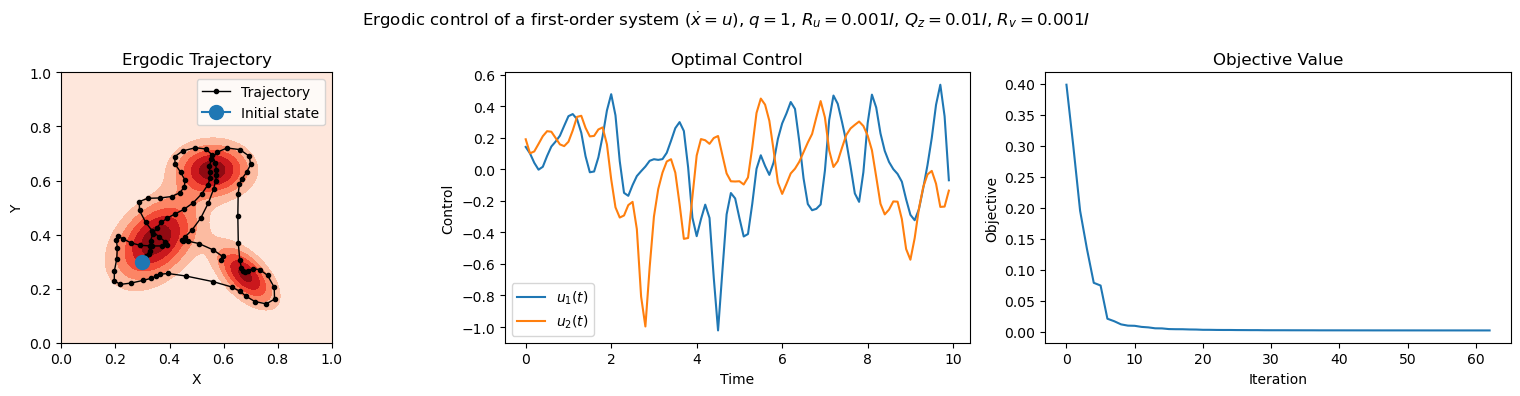

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Ergodic control of a first-order system ($\\dot{x} = u$), '
             '$q = 1$, $R_u = 0.001 I$, $Q_z = 0.01 I$, $R_v = 0.001 I$')

ax = axes[0]
ax.set_aspect('equal')
ax.set_xlim(0.0, L_list[0])
ax.set_ylim(0.0, L_list[1])
ax.contourf(grids_x, grids_y, pdf(grids).reshape(grids_x.shape), cmap='Reds')
ax.plot(np.hstack([x0[0], x_opt[:, 0]]), np.hstack([x0[1], x_opt[:, 1]]),
        linestyle='-', marker='o', color='k', markersize=3, linewidth=1, label='Trajectory')
ax.plot(x0[0], x0[1], marker='o', color='C0', markersize=10, label='Initial state')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Ergodic Trajectory')
ax.legend(loc=1)

ax = axes[1]
ax.plot(tlist, u_opt[:, 0], label='$u_1(t)$')
ax.plot(tlist, u_opt[:, 1], label='$u_2(t)$')
ax.set_xlabel('Time')
ax.set_ylabel('Control')
ax.set_title('Optimal Control')
ax.legend()

ax = axes[2]
ax.plot(np.arange(len(J_list)), J_list)
ax.set_xlabel('Iteration')
ax.set_ylabel('Objective')
ax.set_title('Objective Value')

plt.tight_layout()
plt.show()